# Weekly environment report — map, issue bars, and pies for the issues that dominate

Where environmental issues are being reported across Indonesia, and which issues they are.
A choropleth across the top; below it a horizontal bar chart of issue categories, plus a pie of
provinces for each issue that towers over the rest. Built with `great.viz.environment`.

## One-time setup

The map needs the `[geo]` extra (geopandas, shapely, requests) on top of the usual install:

```
py -3.11 -m pip install -e "C:\Users\ASUS\Documents\Research Project\GREAT Big Data Analysis Program[all]"
```

`[all]` covers it. If you installed with just `[viz]` earlier, re-run the line above — `great.viz.environment`
imports geopandas at module level and will not import without it.

On first use the module downloads the 38-province GeoJSON once and caches it in your user
directory, so that step only costs you network time the first time.

In [1]:
# Pick up edits to the great/ source without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [2]:
import re

import pandas as pd

from great import classify_issue, resolve_frame, validate_export
from great.viz import prep
from great.viz.environment import dominant_issues, env_bar_pies, province_counts

## 1. Load and validate

The export is read straight from Google Sheets, so the notebook runs on any machine without a
local copy of the file. Paste the sheet's link into `SOURCE` — the file must be shared as
"Anyone with the link". Only the file id in the link matters; it is turned into Google's
`export?format=xlsx` download URL, which pandas reads directly.

The environmental export uses the same 13-column schema as every other export in this
portfolio, so `validate_export()` applies unchanged — it fails at load time if a column is
missing or a Sentiment/Media value falls outside the canonical vocabulary.

In [3]:
SOURCE = 'https://docs.google.com/spreadsheets/d/119b-k0DDykSpZJ-BAmIANWKnlfYLBfho/edit?gid=137764228#gid=137764228'

sheet_id = re.search(r'/spreadsheets/d/([\w-]+)', SOURCE).group(1)
df = pd.read_excel(f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx', header=1)
df = validate_export(df)

df1, start_date, end_date = prep.prepare_data(df)
print(f'{len(df1):,} rows | {start_date} - {end_date}')

1,832 rows | 23 Sep 2026 - 23 Sep 2026


## 2. Derive `Isu_Inti` and `Provinsi`

Neither column exists in a raw export — both reports need them, and this is where the rest of
the library does the work.

**The issue category** comes from `classify_issue()`, the keyword rules in `great/issues.py`.

**The province** comes from `resolve_frame()`, which scans the headline and
mention text against the 1,243-entry gazetteer in `great/geo.py` and falls back to the
structured `Location` column only for rows the text cannot place.

Text wins deliberately. In this export `Location` is the *author’s* location — measured over
25k rows the two disagree 74% of the time, with `Location="Jakarta"` on articles about fires
in Kalimantan. For a map of where issues are *happening*, the article text is the right
signal.

It returns `Pulau` as well, which the island bar chart uses.

In [4]:
df1['Isu_Inti'] = df1['Mentions'].map(classify_issue)
df1[['Provinsi', 'Pulau']] = resolve_frame(df1)

counts = df1['Provinsi'].value_counts()
unresolved = counts.get('Tidak Terdeteksi', 0) + counts.get('Provinsi Tidak Spesifik', 0)
print(f'resolved to a province: {len(df1) - unresolved:,} of {len(df1):,} '
      f'({(len(df1) - unresolved) / len(df1):.1%})')
counts.head(10)

resolved to a province: 993 of 1,832 (54.2%)


Provinsi
Tidak Terdeteksi           644
Kalimantan Selatan         206
Provinsi Tidak Spesifik    195
Kalimantan Tengah          188
DKI Jakarta                 77
Jawa Barat                  65
Kalimantan Timur            61
Kalimantan Barat            60
Jawa Timur                  54
Riau                        45
Name: count, dtype: int64

In [5]:
df1['Isu_Inti'].value_counts()

Isu_Inti
Kebakaran lingkungan         1447
Polusi udara                  101
Sampah                         52
Pencemaran air/limbah          38
Satwa/ekosistem                34
Konflik agraria                32
Kekeringan/Krisis Air          31
Deforestasi                    20
Tambang ilegal/ekstraktif      18
Banjir/longsor                 16
Noise/Tidak Relevan            13
Isu lingkungan lain            12
Perubahan iklim/emisi           5
Energi terbarukan (EBT)         5
Konservasi/reboisasi            4
Bencana vulkanik                1
Abrasi/erosi                    1
Krisis Energi Nasional          1
Pemulihan Pascabencana          1
Name: count, dtype: int64

## 3. The weekly figure

`env_bar_pies()` draws the choropleth across the top and the issue breakdown underneath.
Provinces with no cases are left pale; each province with cases gets a badge showing its count.
Rows classified "Noise/Tidak Relevan" are dropped first — they are not environmental issues,
so they count in neither the bars, the map nor the pies.

**Why pies.** The counts above are lopsided: 1,447 → 101 → 52. On one bar chart the top issue
flattens everything else into slivers. `dominant_issues()` finds the widest gap among the top
two and cuts there if the issue above it is at least `dominance_ratio` (default 2) times the
one below. Here 1,447 / 101 = 14.3× beats 101 / 52 = 1.9×, so only "Kebakaran lingkungan"
leaves the bar chart and gets a pie of the provinces it comes from. A week like
743 → 344 → 114 would cut after the second issue instead (3.0× beats 2.2×) and draw two pies.

On a week with no such gap there are no pies, and the bar chart shows every issue.

Each pie shows the top nine provinces, with the remaining provinces as "Lainnya". Rows the
resolver could not place (`Tidak Terdeteksi`, `Provinsi Tidak Spesifik`) are left out of the
pie and counted in a note underneath it. Folded into "Lainnya" they took over half of the
pie, which then said more about the resolver than about where the issue happened.
Percentages are printed only on wedges of 5% or more; smaller ones have no room for them.

`max_dominant` caps the number of pies (default 2). `badge_size` sets the font size of the
count inside each province badge (default 18).

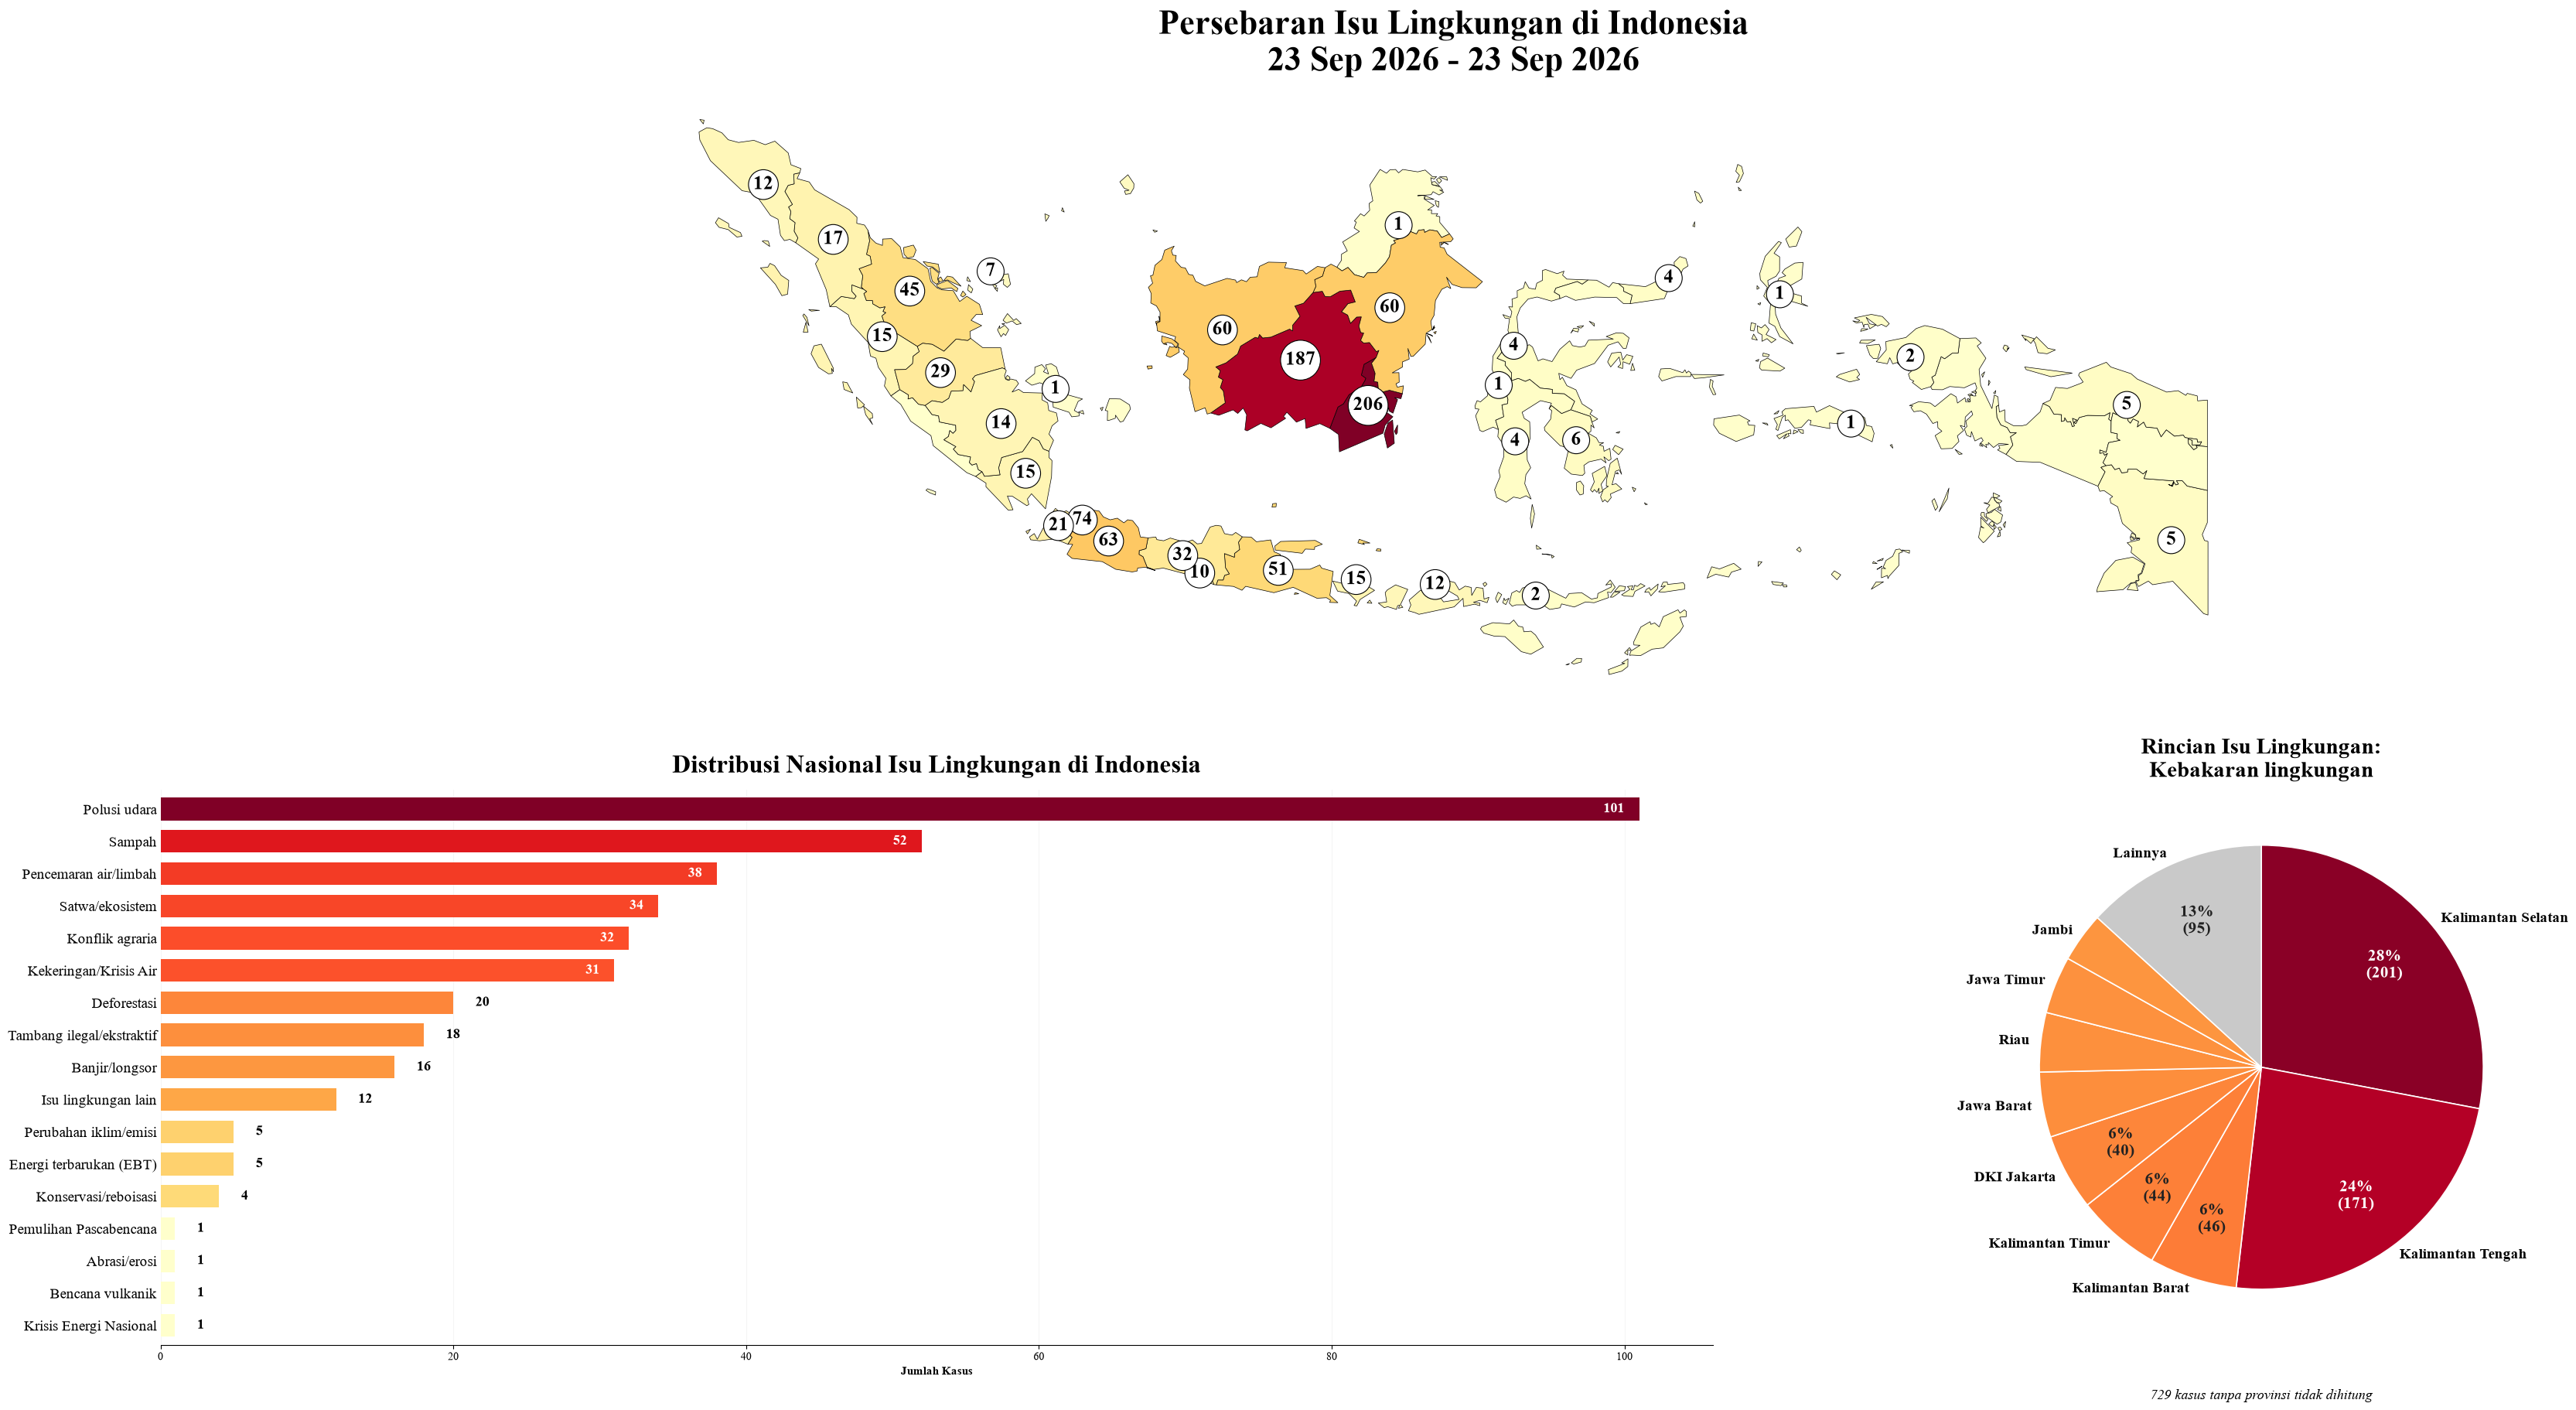

In [6]:
fig = env_bar_pies(
    df1,
    start_date=start_date,
    end_date=end_date,
    dominance_ratio=2.0,   # how lopsided the top issues must be before they become pies
    max_dominant=2,        # at most this many pies
)

## 4. The numbers behind the figure

The same aggregations the report uses, available separately when you want the table rather
than the picture.

In [7]:
print('dominant issues:', dominant_issues(df1['Isu_Inti'].value_counts()))

province_counts(df1).sort_values('jumlah_kasus', ascending=False).head(10)

dominant issues: ['Kebakaran lingkungan']


,Provinsi,jumlah_kasus,provinsi_normalized
34,Tidak Terdeteksi,644,TIDAK TERDETEKSI
10,Kalimantan Selatan,206,KALIMANTAN SELATAN
24,Provinsi Tidak Spesifik,195,PROVINSI TIDAK SPESIFIK
11,Kalimantan Tengah,188,KALIMANTAN TENGAH
4,DKI Jakarta,77,DKI JAKARTA
6,Jawa Barat,65,JAWA BARAT
12,Kalimantan Timur,61,KALIMANTAN TIMUR
9,Kalimantan Barat,60,KALIMANTAN BARAT
8,Jawa Timur,54,JAWA TIMUR
25,Riau,45,RIAU


---

## Where things live

| Import | Contents |
|---|---|
| `great` | `classify_issue`, `resolve`, `resolve_frame`, `validate_export`, label and palette constants |
| `great.geo` | The 572-entry gazetteer, `PROVINCE_FIX`, `GEO_FIX`, `PULAU_MAP`, `ISLAND_ORDER` |
| `great.viz.prep` | `prepare_data()` and the other reshaping helpers |
| `great.viz.environment` | `env_bar_pies()`, `env_one_bar()`, `env_two_bar()`, `dominant_issues()`, `province_counts()`, `island_counts()`, `load_indonesia_geojson()` |

The companion notebook in this folder covers the other report. See `TUTORIAL.md` for the full
library guide and `CONTRIBUTING.md` for how to change it.